In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data_licences = pd.read_parquet("data/data_licences/data_licences.parquet")

In [ ]:
def plot_licencies_age(df, age):
    """ Renvoie un graphique d'évolution des effectifs de licenciés par âge et par sport.

    Paramètres
    ---------
    df (pd.DataFrame) : data frame contenant les données de licences
    age (str) : âge sélectionné
    
    Output
    ---------
    graphique
    """

    df_clean = df[df["code_sport"] != "DIV"]
    df_filtre = df_clean[df_clean["age"] == age]

    table = (
        df_filtre.groupby(["annee", "code_sport"])["licences_annuelles"]
          .sum()
          .unstack()        
          .sort_index()
    )

    plt.figure(figsize=(25, 12))

    for sport in table.columns:
        plt.plot(table.index, table[sport], marker='o', label=sport)

    plt.xlabel("Année")
    plt.ylabel("Nombre de licenciés")
    plt.title(f"Évolution du nombre de licenciés de l'âge de {age} ans par sport")
    plt.legend(title="Sport")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_licencies_age(data_licences, "6")

In [ ]:
def plot_licencies_age_tranche(df, tranche):
    """ Renvoie un graphique d'évolution des effectifs de licenciés par tranche d'âge et par sport.

    Paramètres
    ---------
    df (pd.DataFrame) : data frame contenant les données de licences
    tranche (str) : tranche d'âge sélectionnée, indexée par des lettres (par exemple "a" pour 1 à 4 ans)
    
    Output
    ---------
    graphique
    """

    df_clean = df[df["code_sport"] != "DIV"]
    df_filtre = df_clean[df_clean["tranche_age"].str[0] == tranche]

    table = (
        df_filtre.groupby(["annee", "code_sport"])["licences_annuelles"]
          .sum()
          .unstack()        
          .sort_index()
    )

    plt.figure(figsize=(25, 12))

    for sport in table.columns:
        plt.plot(table.index, table[sport], marker='o', label=sport)

    plt.xlabel("Année")
    plt.ylabel("Nombre de licenciés")
    plt.title(f"Évolution du nombre de licenciés {df_filtre["tranche_age"].str[4:].unique()[0]} ans par sport")
    plt.legend(title="Sport")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_licencies_age_tranche(data_licences, "a")

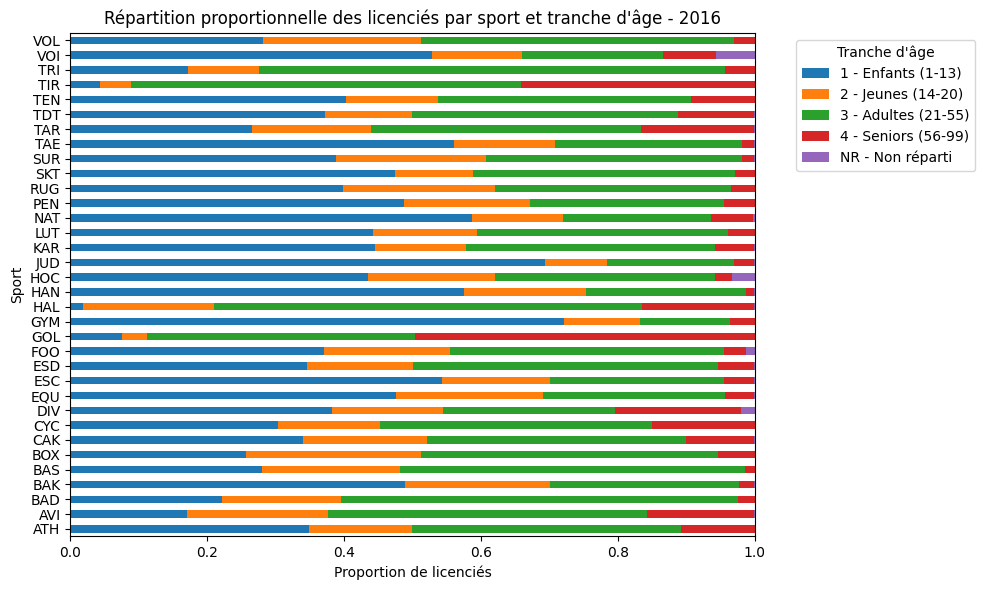

In [ ]:
def sport_age_decomposition(df, annee):
    """ Renvoie un graphique décomposant les effectifs de licenciés par tranche d'âge (grande tranche) et par sport pour une année.

    Paramètres
    ---------
    df (pd.DataFrame) : data frame contenant les données de licences
    annee (int) : année sélectionnée
    
    Output
    ---------
    graphique
    """

    df_clean = df[df["annee"] == annee]

    df_pivot = df_clean.pivot_table(
        index='code_sport',
        columns='grande_tranche_age',
        values='licences_annuelles',
        aggfunc='sum',
        fill_value=0
    )

    df_prop = df_pivot.div(df_pivot.sum(axis=1), axis=0)
    
    df_prop.plot(kind='barh', stacked=True, figsize=(10,6))
    
    plt.title(f"Répartition proportionnelle des licenciés par sport et tranche d'âge - {annee}")
    plt.xlabel("Proportion de licenciés")
    plt.ylabel("Sport")
    plt.legend(title="Tranche d'âge", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0,1)  
    plt.tight_layout()
    plt.show()

sport_age_decomposition(data_licences, 2016)

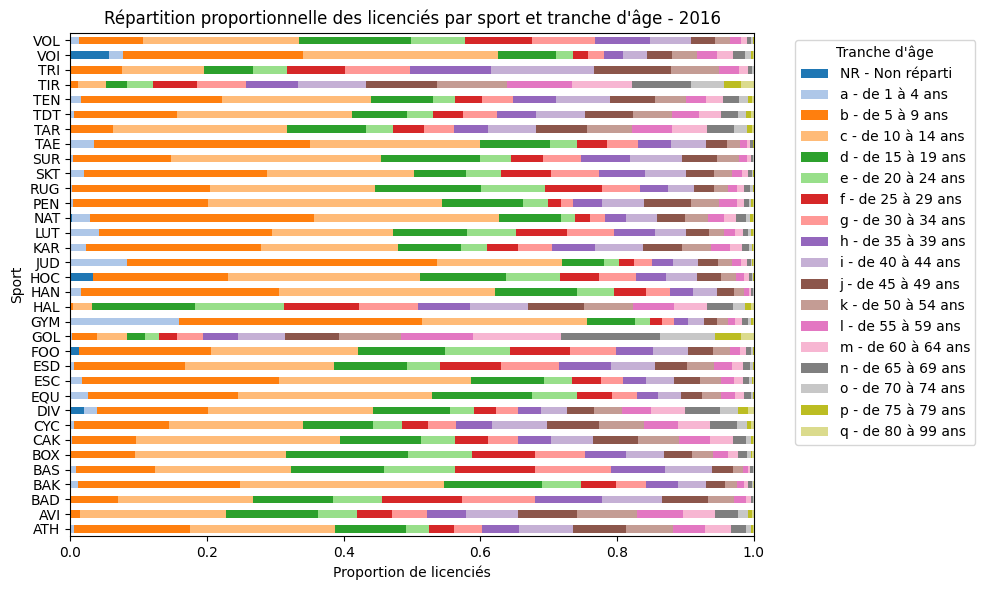

In [ ]:
def sport_age_decomposition_fine(df, annee):
    """ Renvoie un graphique décomposant les effectifs de licenciés par tranche d'âge (tranche d'âge fine) et par sport pour une année.

    Paramètres
    ---------
    df (pd.DataFrame) : data frame contenant les données de licences
    annee (int) : année sélectionnée
    
    Output
    ---------
    graphique
    """

    df_clean = df[df["annee"] == annee]

    df_pivot = df_clean.pivot_table(
        index='code_sport',
        columns='tranche_age',
        values='licences_annuelles',
        aggfunc='sum',
        fill_value=0
    )

    df_prop = df_pivot.div(df_pivot.sum(axis=1), axis=0)

    cmap = plt.get_cmap('tab20')
    couleurs = [cmap(i) for i in range(19)]
    
    df_prop.plot(kind='barh', stacked=True, figsize=(10,6), color=couleurs)
    
    plt.title(f"Répartition proportionnelle des licenciés par sport et tranche d'âge - {annee}")
    plt.xlabel("Proportion de licenciés")
    plt.ylabel("Sport")
    plt.legend(title="Tranche d'âge", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0,1)  
    plt.tight_layout()
    plt.show()

sport_age_decomposition_fine(data_licences, 2016)